In [1]:
import torch
import gpytorch
import numpy as np

In [3]:
# ─── 1. Generate toy data ───────────────────────────────
torch.manual_seed(42)
train_size = 1000

# 50 points, x1 and x2 in [-2, 2]
X_train = torch.rand(train_size, 2) * 4 - 2  

# f(x1,x2) = x1² + sin(x2)
y_train = X_train[:,0] ** 2 + torch.sin(X_train[:,1]) 

# Add small noise, randn generate n value from N(0, 1)
y_train += 0.05 * torch.randn(train_size)             

In [4]:
X_train.shape, y_train.shape

(torch.Size([1000, 2]), torch.Size([1000]))

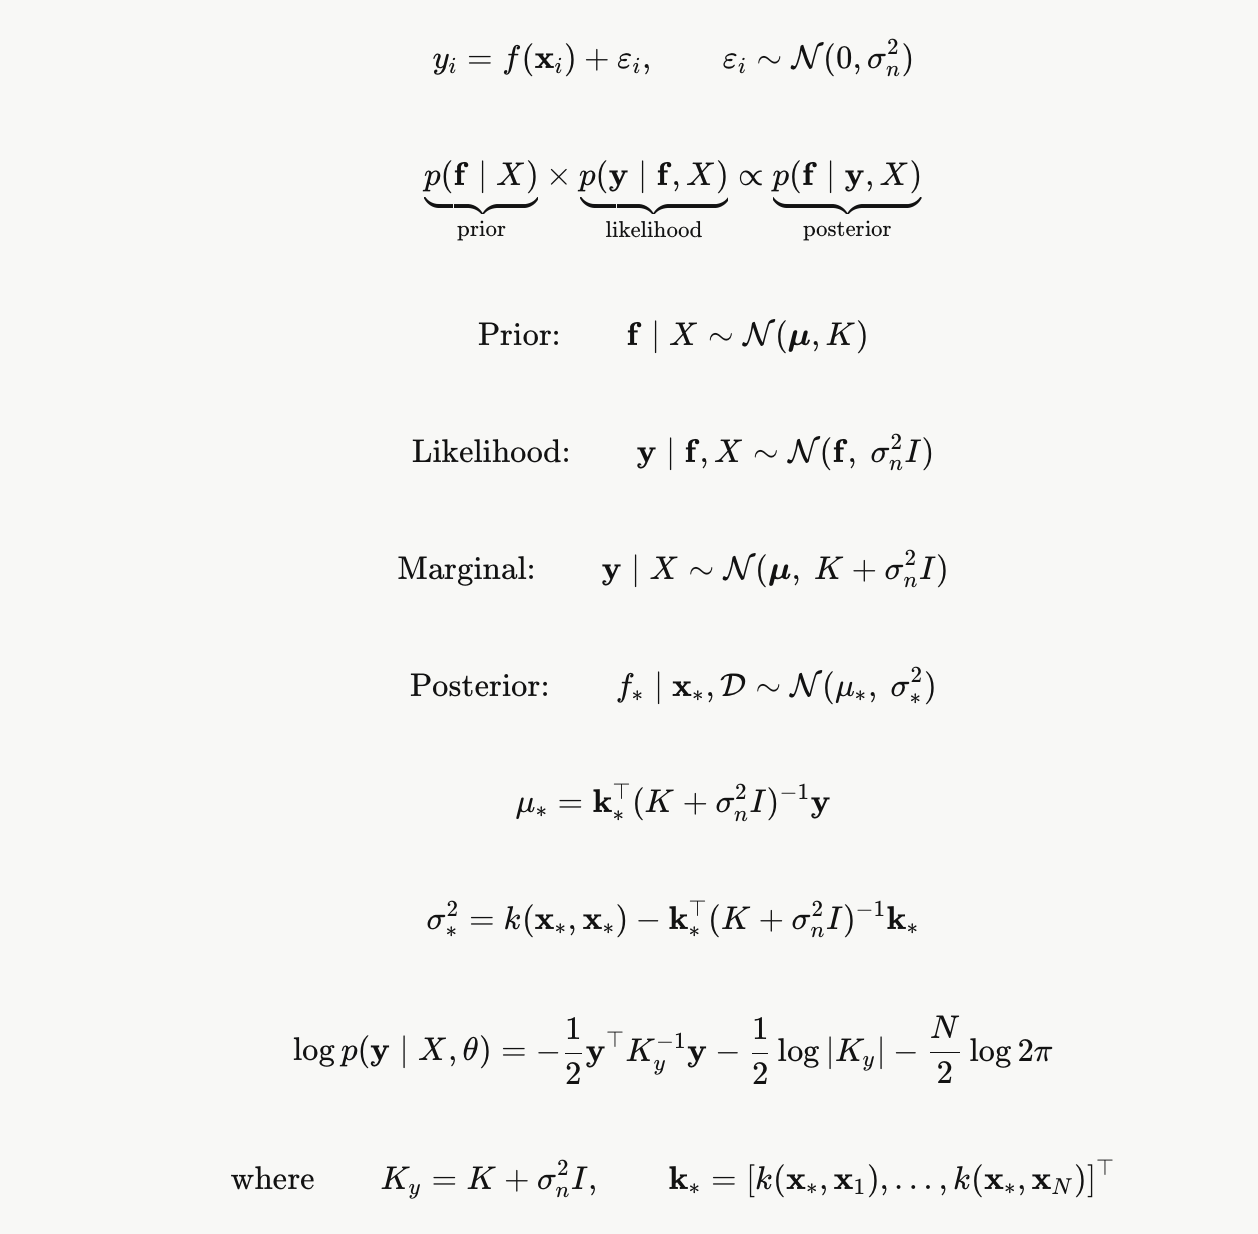

In [5]:
# ─── 2. Define GP model ─────────────────────────────────
# Exact GP Model for small data, no approximation
# Prior: before seeing any data, f is a random function drawn from GP(c, k)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, X_train, y_train, likelihood):
        super().__init__(X_train, y_train, likelihood)
        
        # Learn constant prior mean value during training, better than zero mean
        # It doesn't depend on x at all
        self.mean_module = gpytorch.means.ConstantMean()

        # Define covariance kernel function using RBF kernel
        # learnable scale l controls width of wiggles
        # learnable σf2 amplitude controls height of the wiggles
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    # Define prior distribution: What the GP believes about the function before seeing any data 
    # p(f | X)
    def forward(self, x):
        mean = self.mean_module(x) # calls constantmean and returns a vector of the constant c repeated N times
        covar = self.covar_module(x) # returns the NxN kernel matrix K
        return gpytorch.distributions.MultivariateNormal(
            mean, # type: ignore
            covar 
        )

In [6]:
# ─── 3. Train/Initialize hyperparameters ───────────────────────────

# Create likelihood object
likelihood = gpytorch.likelihoods.GaussianLikelihood()

# Initiate GP model
model = ExactGPModel(X_train, y_train, likelihood)

model.train()
likelihood.train()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [7]:
# Create an Adam optimizer that will update all learnable parameters theta = (c,ℓ,σf2​,σn2​) with lr = 0.1
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Define loss function, log of multivariate Gaussian PDF
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model) 

In [8]:
# Actual training loop
for i in range(100):
    optimizer.zero_grad() # clear gradients from the previous iteration

    # Takes prior p(f|X) and add likelihood and compute log p(y|X, theta), sign - to minimize
    loss = -mll(model(X_train), y_train) # type: ignore
    
    # Compute gradients
    loss.backward() 

    # Update hyperparameters by ADAM momentum
    optimizer.step() 


print(f"Learned length scale: {model.covar_module.base_kernel.lengthscale.item():.4f}")
print(f"Learned noise:        {likelihood.noise.item():.4f}")


Learned length scale: 1.7751
Learned noise:        0.0026


In [9]:
# ─── 4. Predict + analytic gradient ─────────────────────

# Tells GPyTorch to switch from prior mode to posterior mode
model.eval()
likelihood.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [10]:
X_test = torch.rand(200, 2) * 4 - 2
# Tells PyTorch to track all computations involving `X_test` 
X_test.requires_grad_(True)

with gpytorch.settings.fast_pred_var():
    # Posterior over latent function p(f∗​∣x∗​,D)=N(μ∗​,σ∗2​)
    posterior = model(X_test)

    # adds noise to get predictive distribution over observations
    pred = likelihood(posterior)

    # extract posterior mean
    mu = pred.mean

# mu.sum().backward()
# grad_mu = X_test.grad.detach()       # type: ignore # ∇μ*(x), shape (200, 2)


In [12]:
# Create a 2D grid for plotting
n = 50  # 50x50 grid
x1 = torch.linspace(-2, 2, n)
x2 = torch.linspace(-2, 2, n)
xx1, xx2 = torch.meshgrid(x1, x2, indexing='ij')
X_grid = torch.stack([xx1.flatten(), xx2.flatten()], dim=1)  # (2500, 2)
X_grid.requires_grad_(True)

tensor([[-2.0000, -2.0000],
        [-2.0000, -1.9184],
        [-2.0000, -1.8367],
        ...,
        [ 2.0000,  1.8367],
        [ 2.0000,  1.9184],
        [ 2.0000,  2.0000]], requires_grad=True)

In [13]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(X_grid))
    mu  = pred.mean.reshape(n, n).numpy()         # posterior mean
    std = pred.variance.sqrt().reshape(n, n).detach().numpy()  # posterior std = bandwidth

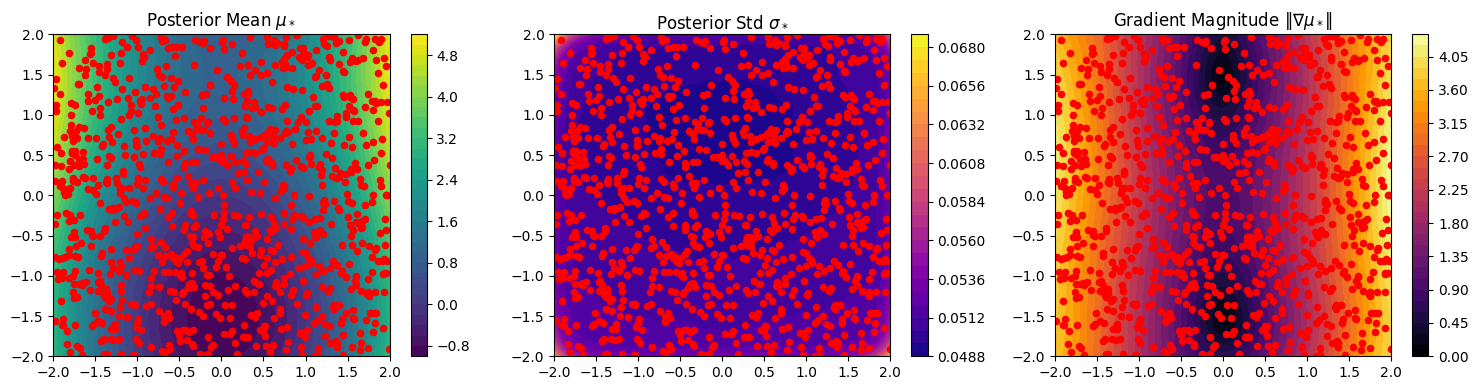

In [14]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import gpytorch

xx1_np = xx1.numpy()
xx2_np = xx2.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Posterior mean ──────────────────────────────────────
im0 = axes[0].contourf(xx1_np, xx2_np, mu, levels=30, cmap='viridis')
axes[0].scatter(X_train[:,0], X_train[:,1], c='red', s=20, label='train points')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Posterior Mean $\\mu_*$')

# ── Posterior std (bandwidth/uncertainty) ───────────────
im1 = axes[1].contourf(xx1_np, xx2_np, std, levels=30, cmap='plasma')
axes[1].scatter(X_train[:,0], X_train[:,1], c='red', s=20)
plt.colorbar(im1, ax=axes[1])
axes[1].set_title('Posterior Std $\\sigma_*$')

# ── Gradient magnitude ──────────────────────────────────
# Need grad, so recompute with requires_grad
X_grid2 = torch.stack([xx1.flatten(), xx2.flatten()], dim=1)
X_grid2.requires_grad_(True)
with gpytorch.settings.fast_pred_var():
    mu_grad = likelihood(model(X_grid2)).mean
mu_grad.sum().backward()
grad = X_grid2.grad.detach().norm(dim=1).reshape(n, n).numpy()

im2 = axes[2].contourf(xx1_np, xx2_np, grad, levels=30, cmap='inferno')
axes[2].scatter(X_train[:,0], X_train[:,1], c='red', s=20)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title('Gradient Magnitude $\\|\\nabla \\mu_*\\|$')

plt.tight_layout()
plt.savefig('gp_posterior.png', dpi=150)
plt.show()